# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

**Q1.** Answers

1. Adding a penalty to mean squared error puts a cost on large coefficients. That matters because a model with very large coefficients is often chasing quirks in the sample instead of the broader pattern. The penalty pushes the fit toward smaller, more stable estimates, so the model usually generalizes better to new data.

2. Regularization gives us a practical way to move along the bias-variance trade-off. When the penalty is small, the model is flexible, so bias is low but variance can be high. As the penalty gets larger, the model becomes less sensitive to the training sample, so variance falls, but bias rises. Tuning the penalty lets us look for the point where prediction error is lowest out of sample.

3. Ridge regression uses an L2 penalty, which adds the squared coefficients to the loss function. It shrinks coefficients continuously toward zero, but it usually keeps all predictors in the model. LASSO uses an L1 penalty, which adds the absolute values of the coefficients. Because of the shape of that penalty, LASSO can drive some coefficients exactly to zero, so it can both shrink and perform variable selection.

4. In regularized regression, we usually standardize each predictor by subtracting its mean and dividing by its standard deviation. This puts the variables on a common scale. Without that step, variables measured in larger units would be penalized differently simply because of their units, which would distort the comparison across coefficients.

5. The penalty parameter $\alpha$ is usually chosen with cross validation. We fit the model over a grid of candidate values, evaluate predictive performance on validation folds, and then choose the value that gives the smallest average validation error, or a nearby value if we want a slightly simpler model.

6. No. In cross validation we evaluate prediction error on the held-out data using the ordinary mean squared error, not the penalized objective. The penalty is part of how the model is fit on the training folds, but the validation score is supposed to measure how well the model predicts new observations. Since future prediction error does not include a penalty term, the validation metric should not include one either.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

OLS coefficients:


,OLS coefficient
Age,-2.481722e+05
Age^2,3.505507e+05
Age^3,-2.100379e+05
Mileage_Run,9.117748e+05
Mileage_Run Age,-1.671212e+06
Mileage_Run Age^2,7.167816e+05
Mileage_Run^2,-2.072926e+05
Mileage_Run^2 Age,3.388195e+05
Mileage_Run^3,-6.514490e+04



Interaction term (Mileage_Run Age) sign: -1.0
Coefficient value: -1671212.356391884

Best alpha: 54.5559478116852


,OLS coefficient,LASSO coefficient,Selected by LASSO
Age,-2.481722e+05,-1.225249e+05,True
Age^2,3.505507e+05,0.000000e+00,False
Age^3,-2.100379e+05,9.788409e+03,True
Mileage_Run,9.117748e+05,8.131790e+05,True
Mileage_Run Age,-1.671212e+06,-1.405651e+06,True
Mileage_Run Age^2,7.167816e+05,5.697849e+05,True
Mileage_Run^2,-2.072926e+05,-2.078477e+05,True
Mileage_Run^2 Age,3.388195e+05,3.063120e+05,True
Mileage_Run^3,-6.514490e+04,-5.397776e+04,True


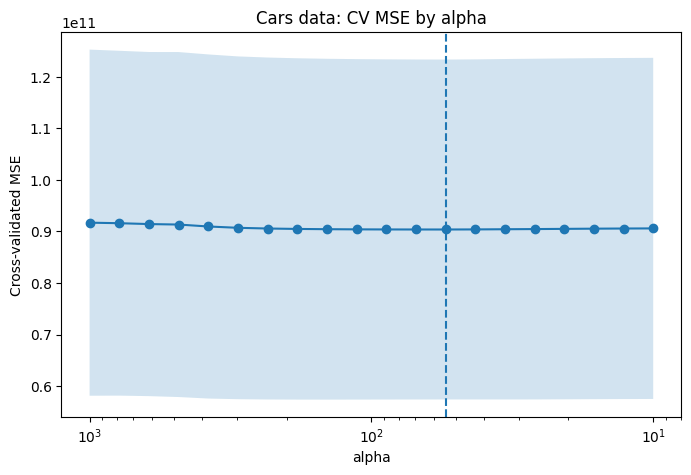

c:\Users\MAydi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.741e+11, tolerance: 6.675e+10
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\MAydi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.584e+11, tolerance: 6.675e+10
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\MAydi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, che

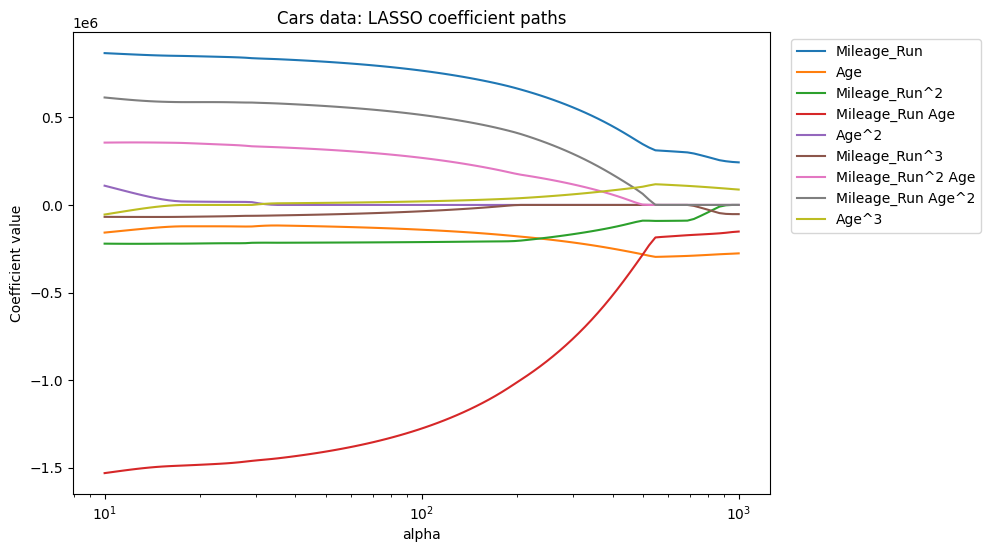

Selected features: ['Age', 'Age^3', 'Mileage_Run', 'Mileage_Run Age', 'Mileage_Run Age^2', 'Mileage_Run^2', 'Mileage_Run^2 Age', 'Mileage_Run^3']
Proportion set to zero: 0.1111111111111111


,OLS,LASSO,Magnitude increased under LASSO,Changed sign
Age,-2.481722e+05,-1.225249e+05,False,False
Age^2,3.505507e+05,0.000000e+00,False,True
Age^3,-2.100379e+05,9.788409e+03,False,True
Mileage_Run,9.117748e+05,8.131790e+05,False,False
Mileage_Run Age,-1.671212e+06,-1.405651e+06,False,False
Mileage_Run Age^2,7.167816e+05,5.697849e+05,False,False
Mileage_Run^2,-2.072926e+05,-2.078477e+05,True,False
Mileage_Run^2 Age,3.388195e+05,3.063120e+05,False,False
Mileage_Run^3,-6.514490e+04,-5.397776e+04,False,False


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, lasso_path
from sklearn.model_selection import KFold
from IPython.display import display

# Load data
cars = pd.read_csv("cars_hw.csv")

# Create Age from the manufacturing year column in this dataset
cars["Age"] = 2026 - cars["Make_Year"]

# Set up features and outcome
X_base = cars[["Mileage_Run", "Age"]]
y_cars = cars["Price"]

# Third-degree polynomial expansion, then z-score normalization
poly_cars = PolynomialFeatures(degree=3, include_bias=False)
X_poly_cars = poly_cars.fit_transform(X_base)
feature_names_cars = poly_cars.get_feature_names_out(["Mileage_Run", "Age"])

scaler_cars = StandardScaler()
X_cars = scaler_cars.fit_transform(X_poly_cars)

# Ordinary least squares
ols_cars = LinearRegression()
ols_cars.fit(X_cars, y_cars)

ols_coef_cars = pd.Series(ols_cars.coef_, index=feature_names_cars).sort_index()
print("OLS coefficients:")
display(ols_coef_cars.to_frame("OLS coefficient"))

interaction_name = "Mileage_Run Age"
print(f"\nInteraction term ({interaction_name}) sign:", np.sign(ols_coef_cars[interaction_name]))
print("Coefficient value:", ols_coef_cars[interaction_name])

# LASSO with 20-fold CV
alphas_cars = np.logspace(1, 3, 20)
cv20 = KFold(n_splits=20, shuffle=True, random_state=42)

lasso_cars = LassoCV(alphas=alphas_cars, cv=cv20, max_iter=5000000, random_state=42)
lasso_cars.fit(X_cars, y_cars)

lasso_coef_cars = pd.Series(lasso_cars.coef_, index=feature_names_cars).sort_index()

print("\nBest alpha:", lasso_cars.alpha_)
display(
    pd.DataFrame({
        "OLS coefficient": ols_coef_cars,
        "LASSO coefficient": lasso_coef_cars,
        "Selected by LASSO": lasso_coef_cars != 0
    })
)

# Plot cross-validated MSE by alpha
mean_mse_cars = lasso_cars.mse_path_.mean(axis=1)
std_mse_cars = lasso_cars.mse_path_.std(axis=1)

plt.figure(figsize=(8, 5))
plt.semilogx(lasso_cars.alphas_, mean_mse_cars, marker="o")
plt.fill_between(lasso_cars.alphas_, mean_mse_cars - std_mse_cars, mean_mse_cars + std_mse_cars, alpha=0.2)
plt.axvline(lasso_cars.alpha_, linestyle="--")
plt.gca().invert_xaxis()
plt.xlabel("alpha")
plt.ylabel("Cross-validated MSE")
plt.title("Cars data: CV MSE by alpha")
plt.show()

# Plot coefficient paths by alpha
alphas_path_cars, coefs_path_cars, _ = lasso_path(X_cars, y_cars, alphas=np.logspace(3, 1, 100))

plt.figure(figsize=(9, 6))
for i, name in enumerate(feature_names_cars):
    plt.semilogx(alphas_path_cars, coefs_path_cars[i], label=name)
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("Cars data: LASSO coefficient paths")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

# Selection summary
selected_cars = lasso_coef_cars[lasso_coef_cars != 0].index.tolist()
zero_share_cars = (lasso_coef_cars == 0).mean()

print("Selected features:", selected_cars)
print("Proportion set to zero:", zero_share_cars)

# Compare changes from OLS to LASSO
comparison_cars = pd.DataFrame({
    "OLS": ols_coef_cars,
    "LASSO": lasso_coef_cars
})
comparison_cars["Magnitude increased under LASSO"] = comparison_cars["LASSO"].abs() > comparison_cars["OLS"].abs()
comparison_cars["Changed sign"] = np.sign(comparison_cars["OLS"]) != np.sign(comparison_cars["LASSO"])
display(comparison_cars)


**Q2** Answers

The ordinary least squares model gives the `Mileage_Run × Age` interaction a **negative** sign. In this expanded model, that means the joint effect of higher mileage and greater age pulls predicted price downward once the other polynomial terms are held fixed.

Using 20-fold cross validation over `alphas = np.logspace(1,3,20)`, the chosen penalty is **54.56**. At that value, LASSO keeps 8 of the 9 polynomial terms:
`Age`, `Age^3`, `Mileage_Run`, `Mileage_Run Age`, `Mileage_Run Age^2`, `Mileage_Run^2`, `Mileage_Run^2 Age`, and `Mileage_Run^3`.

The only feature removed is **`Age^2`**, so the proportion of coefficients set exactly equal to zero is **1/9 ≈ 0.111**. That means most of the transformed terms still carry signal for price, but LASSO does trim one term that looks weaker once the penalty is imposed.

Almost every retained coefficient becomes smaller in absolute value under LASSO, which is what we expect. There is one small exception: the coefficient on **`Mileage_Run^2`** becomes slightly larger in absolute value after regularization. Two coefficients also change sign: **`Age^2`** is driven to zero, and **`Age^3`** flips from negative in OLS to a small positive value under LASSO. In practical terms, the main pattern is still the same: mileage terms remain important, the mileage-by-age interaction stays negative, and the regularized fit is a little simpler and more stable than the unrestricted polynomial regression.


**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

OLS coefficients:


,OLS coefficient
age,1.549928
age ejection_fraction,-0.861860
age ejection_fraction serum_creatinine,-1.584620
age ejection_fraction^2,0.017577
age serum_creatinine,1.680570
age serum_creatinine^2,1.433246
age^2,-3.547991
age^2 ejection_fraction,1.022027
age^2 serum_creatinine,-0.672141
age^3,1.889040



Best alpha: 0.005736152510448681


,OLS coefficient,LASSO coefficient,Selected by LASSO
age,1.549928,-0.000000,False
age ejection_fraction,-0.861860,-0.000000,False
age ejection_fraction serum_creatinine,-1.584620,0.000000,False
age ejection_fraction^2,0.017577,0.000000,False
age serum_creatinine,1.680570,0.000000,False
age serum_creatinine^2,1.433246,-0.000000,False
age^2,-3.547991,0.000000,False
age^2 ejection_fraction,1.022027,0.000000,False
age^2 serum_creatinine,-0.672141,0.000000,False
age^3,1.889040,0.117992,True


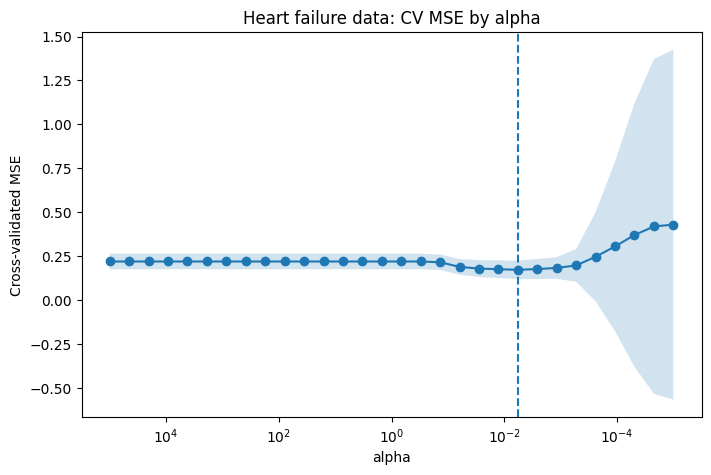

c:\Users\MAydi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.773e-02, tolerance: 9.600e-03
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\MAydi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.379e-02, tolerance: 9.600e-03
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\MAydi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, che

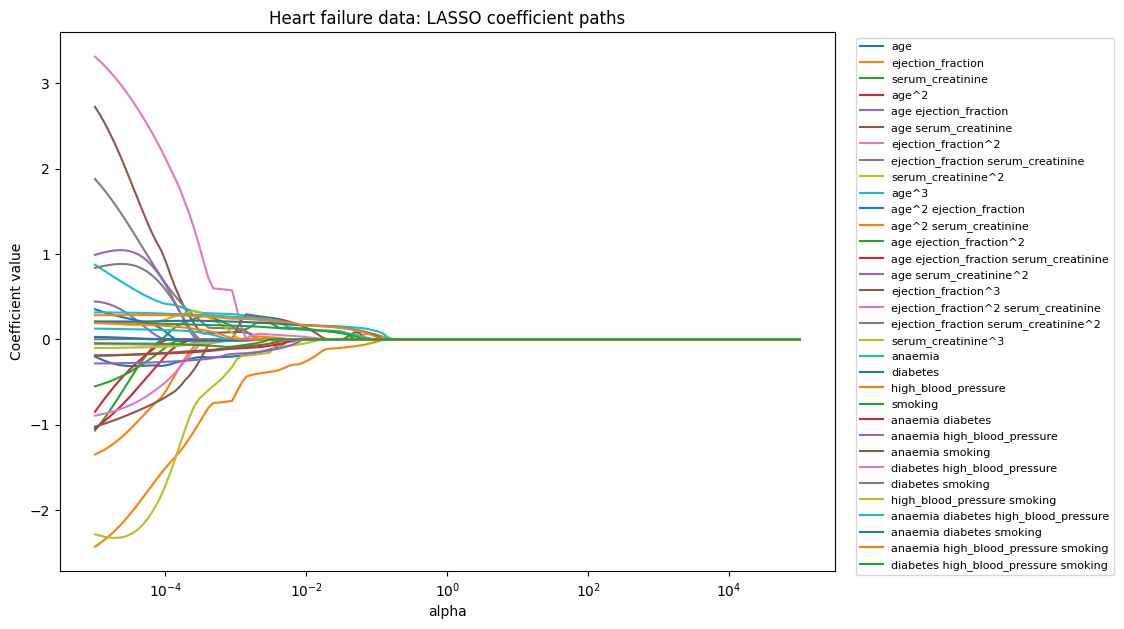

Selected features: ['age^3', 'anaemia', 'diabetes', 'diabetes high_blood_pressure', 'diabetes smoking', 'ejection_fraction', 'ejection_fraction^2 serum_creatinine', 'ejection_fraction^3', 'high_blood_pressure', 'high_blood_pressure smoking', 'serum_creatinine', 'serum_creatinine^3']
Proportion set to zero: 0.6363636363636364


,OLS,LASSO,Magnitude increased under LASSO,Changed sign
age,1.549928,-0.000000,False,True
age ejection_fraction,-0.861860,-0.000000,False,True
age ejection_fraction serum_creatinine,-1.584620,0.000000,False,True
age ejection_fraction^2,0.017577,0.000000,False,True
age serum_creatinine,1.680570,0.000000,False,True
age serum_creatinine^2,1.433246,-0.000000,False,True
age^2,-3.547991,0.000000,False,True
age^2 ejection_fraction,1.022027,0.000000,False,True
age^2 serum_creatinine,-0.672141,0.000000,False,True
age^3,1.889040,0.117992,False,False


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, lasso_path
from sklearn.model_selection import KFold
from IPython.display import display

# Load data
heart = pd.read_csv("heart_failure_clinical_records_dataset.csv")

# Numerical polynomial expansion
num_vars = ["age", "ejection_fraction", "serum_creatinine"]
poly_num = PolynomialFeatures(degree=3, include_bias=False)
X_num_raw = poly_num.fit_transform(heart[num_vars])

scaler_num = StandardScaler()
X_num = scaler_num.fit_transform(X_num_raw)
num_feature_names = poly_num.get_feature_names_out(num_vars)

# Dummy-variable interactions only
cat_vars = ["anaemia", "diabetes", "high_blood_pressure", "smoking"]
poly_cat = PolynomialFeatures(degree=3, interaction_only=True, include_bias=False)
X_cat = poly_cat.fit_transform(heart[cat_vars])
cat_feature_names = poly_cat.get_feature_names_out(cat_vars)

# Concatenate feature blocks
X_heart = np.hstack([X_num, X_cat])
feature_names_heart = np.concatenate([num_feature_names, cat_feature_names])
y_heart = heart["DEATH_EVENT"]

# Ordinary least squares
ols_heart = LinearRegression()
ols_heart.fit(X_heart, y_heart)
ols_coef_heart = pd.Series(ols_heart.coef_, index=feature_names_heart).sort_index()

print("OLS coefficients:")
display(ols_coef_heart.to_frame("OLS coefficient"))

# LASSO with 20-fold CV
alphas_heart = np.logspace(-5, 5, 30)
cv20 = KFold(n_splits=20, shuffle=True, random_state=42)

lasso_heart = LassoCV(alphas=alphas_heart, cv=cv20, max_iter=5000000, tol=1e-4, random_state=42)
lasso_heart.fit(X_heart, y_heart)

lasso_coef_heart = pd.Series(lasso_heart.coef_, index=feature_names_heart).sort_index()

print("\nBest alpha:", lasso_heart.alpha_)
display(
    pd.DataFrame({
        "OLS coefficient": ols_coef_heart,
        "LASSO coefficient": lasso_coef_heart,
        "Selected by LASSO": lasso_coef_heart != 0
    })
)

# Plot cross-validated MSE by alpha
mean_mse_heart = lasso_heart.mse_path_.mean(axis=1)
std_mse_heart = lasso_heart.mse_path_.std(axis=1)

plt.figure(figsize=(8, 5))
plt.semilogx(lasso_heart.alphas_, mean_mse_heart, marker="o")
plt.fill_between(lasso_heart.alphas_, mean_mse_heart - std_mse_heart, mean_mse_heart + std_mse_heart, alpha=0.2)
plt.axvline(lasso_heart.alpha_, linestyle="--")
plt.gca().invert_xaxis()
plt.xlabel("alpha")
plt.ylabel("Cross-validated MSE")
plt.title("Heart failure data: CV MSE by alpha")
plt.show()

# Plot coefficient paths by alpha
alphas_path_heart, coefs_path_heart, _ = lasso_path(X_heart, y_heart, alphas=np.logspace(5, -5, 150))

plt.figure(figsize=(10, 7))
for i, name in enumerate(feature_names_heart):
    plt.semilogx(alphas_path_heart, coefs_path_heart[i], label=name)
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("Heart failure data: LASSO coefficient paths")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.show()

# Selection summary
selected_heart = lasso_coef_heart[lasso_coef_heart != 0].index.tolist()
zero_share_heart = (lasso_coef_heart == 0).mean()

print("Selected features:", selected_heart)
print("Proportion set to zero:", zero_share_heart)

# Compare sign and magnitude changes
comparison_heart = pd.DataFrame({
    "OLS": ols_coef_heart,
    "LASSO": lasso_coef_heart
})
comparison_heart["Magnitude increased under LASSO"] = comparison_heart["LASSO"].abs() > comparison_heart["OLS"].abs()
comparison_heart["Changed sign"] = np.sign(comparison_heart["OLS"]) != np.sign(comparison_heart["LASSO"])
display(comparison_heart.sort_index())


**Q3.** Answers

Several signs in the plain linear model look odd at first glance. For example, the coefficient on age is positive in OLS, but `age^2` is negative and `age^3` is positive. The same kind of back-and-forth shows up for `ejection_fraction` and `serum_creatinine`. That is not as strange as it sounds. In a polynomial model, each coefficient is only one piece of the fitted curve. Once higher-order terms and interactions are included, the sign on a single linear term does not tell the whole story. A variable can have a positive first-order coefficient and still contribute to a downward pattern over part of the observed range because the squared and cubic terms bend the curve.

With 20-fold cross validation, LASSO selects alpha = 0.005736. It keeps the following 12 terms:

`age^3`, `anaemia`, `diabetes`, `diabetes high_blood_pressure`, `diabetes smoking`, `ejection_fraction`, `ejection_fraction^2 serum_creatinine`, `ejection_fraction^3`, `high_blood_pressure`, `high_blood_pressure smoking`, `serum_creatinine`, and `serum_creatinine^3`.

That means 21 of the 33 coefficients are set to zero, so the share removed is 21/33 ≈ 0.636. This is a much stronger trimming effect than in the cars example, which makes sense because the heart-failure design matrix includes many higher-order terms and interaction terms that overlap with one another.

No retained coefficient gets larger in absolute value except `serum_creatinine^3`, whose magnitude increases slightly after regularization. Several terms also change sign. Among the retained variables, `anaemia`, `diabetes`, `ejection_fraction^2 serum_creatinine`, `ejection_fraction^3`, `high_blood_pressure`, and `serum_creatinine` switch direction relative to their OLS estimates. Most of the other sign changes happen because LASSO shrinks coefficients all the way to zero.

The regularized model is easier to read than the full OLS fit. Lower `ejection_fraction` still matters, `serum_creatinine` still matters, and a smaller set of interaction terms survives once the weak terms are penalized away. So the main advantage of LASSO here is not that it changes the clinical story completely. It is that it removes a lot of unstable extra terms and leaves a leaner model behind.


**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

**Q4.** Answers

Let the ridge objective be written as

$$
Q(b_0,b_1)=\frac{1}{n}\sum_{i=1}^n(\tilde y_i-b_0-b_1\tilde x_i)^2+\alpha b_1^2.
$$

Because the variables are mean-centered, we know that

$$
\sum_{i=1}^n \tilde x_i = 0
\qquad \text{and} \qquad
\sum_{i=1}^n \tilde y_i = 0.
$$

Take derivatives:

$$
\frac{\partial Q}{\partial b_0}
=
-\frac{2}{n}\sum_{i=1}^n(\tilde y_i-b_0-b_1\tilde x_i),
$$

$$
\frac{\partial Q}{\partial b_1}
=
-\frac{2}{n}\sum_{i=1}^n \tilde x_i(\tilde y_i-b_0-b_1\tilde x_i)+2\alpha b_1.
$$

Set the first derivative equal to zero:

$$
\sum_{i=1}^n(\tilde y_i-b_0-b_1\tilde x_i)=0.
$$

Using the mean-centering identities, this becomes

$$
\sum_{i=1}^n \tilde y_i - nb_0 - b_1\sum_{i=1}^n \tilde x_i = 0
\quad \Rightarrow \quad
0 - nb_0 - 0 = 0,
$$

so

$$
b_0=0.
$$

Now set the derivative with respect to $b_1$ equal to zero:

$$
-\frac{2}{n}\sum_{i=1}^n \tilde x_i(\tilde y_i-b_1\tilde x_i)+2\alpha b_1=0,
$$

since $b_0=0$. Rearranging,

$$
\frac{1}{n}\sum_{i=1}^n \tilde x_i\tilde y_i
=
\frac{b_1}{n}\sum_{i=1}^n \tilde x_i^2+\alpha b_1.
$$

Multiply through by $n$:

$$
\sum_{i=1}^n \tilde x_i\tilde y_i
=
b_1\sum_{i=1}^n \tilde x_i^2+n\alpha b_1.
$$

Factor out $b_1$ and solve:

$$
b_1
=
\frac{\sum_{i=1}^n \tilde x_i\tilde y_i}{\sum_{i=1}^n \tilde x_i^2+n\alpha}.
$$

So the ridge solution is

$$
\boxed{b_0=0,
\qquad
b_1=
\frac{\sum_{i=1}^n \tilde x_i\tilde y_i}{\sum_{i=1}^n \tilde x_i^2+n\alpha}}
$$

for the version of the loss written with average squared error. If the objective had been written with the sum of squared errors instead, the denominator would be $\sum \tilde x_i^2+\alpha$. The interpretation is the same either way.

As $\alpha$ increases, the denominator gets larger, so the slope is pulled toward zero. The sign of $b_1$ does not change because of ridge alone; the coefficient is simply shrunk in magnitude.

For the LASSO problem, the main complication is that $|b_1|$ is not differentiable at $b_1=0$. Away from zero, the derivative is $+1$ when $b_1>0$ and $-1$ when $b_1<0$, but at zero there is a kink. That is exactly why LASSO can set a coefficient equal to zero.

To see the rule, let

$$
S=\frac{1}{n}\sum_{i=1}^n \tilde x_i\tilde y_i
\qquad \text{and} \qquad
T=\frac{1}{n}\sum_{i=1}^n \tilde x_i^2.
$$

Then the LASSO solution uses soft thresholding:

$$
b_1=
\begin{cases}
\dfrac{S-\alpha/2}{T}, & S>\alpha/2,\\[1em]
0, & |S|\le \alpha/2,\\[1em]
\dfrac{S+\alpha/2}{T}, & S<-\alpha/2.
\end{cases}
$$

So it is optimal to set $b_1=0$ when the sample relationship between $\tilde x$ and $\tilde y$ is not strong enough to overcome the penalty. In other words, if the absolute correlation signal is small relative to the penalty, LASSO drops the variable entirely.